# Advanced EDA
Advanced exploratory data analysis for the `movies.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# Load the dataset
df = pd.read_csv('../datasets/movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [2]:
# 1. Data Cleaning & Feature Engineering

# Handle missing values: dropping purely for cleaner correlation tests
df = df.dropna()

# Convert data types safely
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

# Extract correct release year from the 'released' string 
# (e.g., 'June 13, 1980 (United States)')
df['year_correct'] = df['released'].astype(str).str.extract(r'(\d{4})')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5421 entries, 0 to 7652
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          5421 non-null   object 
 1   rating        5421 non-null   object 
 2   genre         5421 non-null   object 
 3   year          5421 non-null   int64  
 4   released      5421 non-null   object 
 5   score         5421 non-null   float64
 6   votes         5421 non-null   float64
 7   director      5421 non-null   object 
 8   writer        5421 non-null   object 
 9   star          5421 non-null   object 
 10  country       5421 non-null   object 
 11  budget        5421 non-null   int64  
 12  gross         5421 non-null   int64  
 13  company       5421 non-null   object 
 14  runtime       5421 non-null   float64
 15  year_correct  5421 non-null   object 
dtypes: float64(3), int64(3), object(10)
memory usage: 720.0+ KB


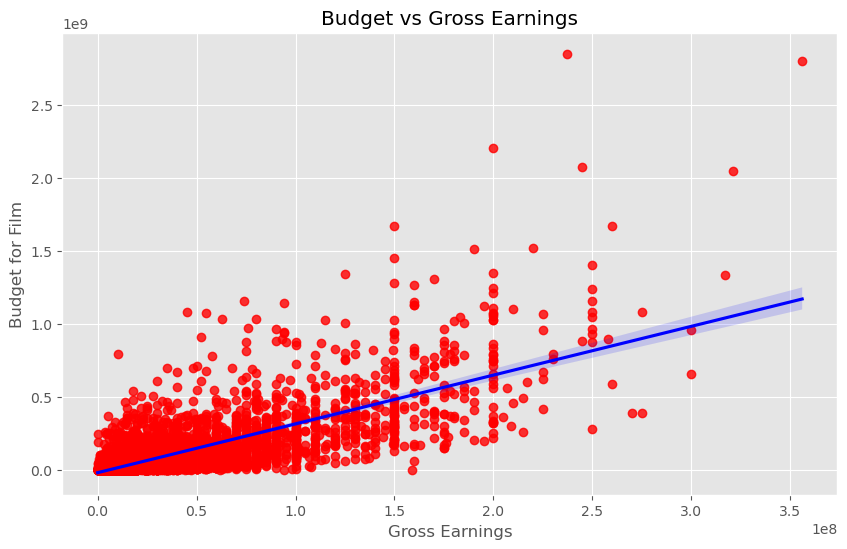

In [3]:
# 2. Bivariate Analysis: Scatter & Regression (Budget vs Gross)

# Are higher budgets consistently leading to higher gross revenue?
plt.figure(figsize=(10,6))
sns.regplot(x="budget", y="gross", data=df, 
            scatter_kws={"color": "red"}, line_kws={"color": "blue"})
plt.title('Budget vs Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget for Film')
plt.show()

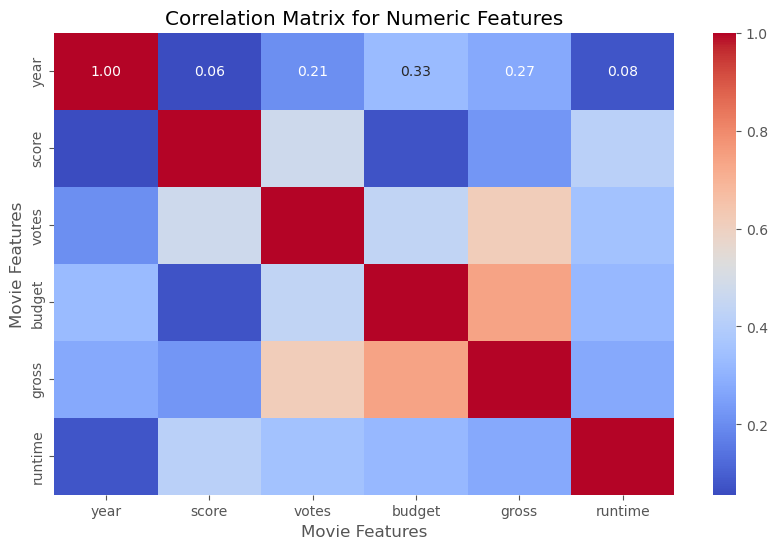

In [4]:
# 3. Numeric Correlation Analysis

# Using Pearson correlation to see linear relationships.
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr(method='pearson')

# Heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

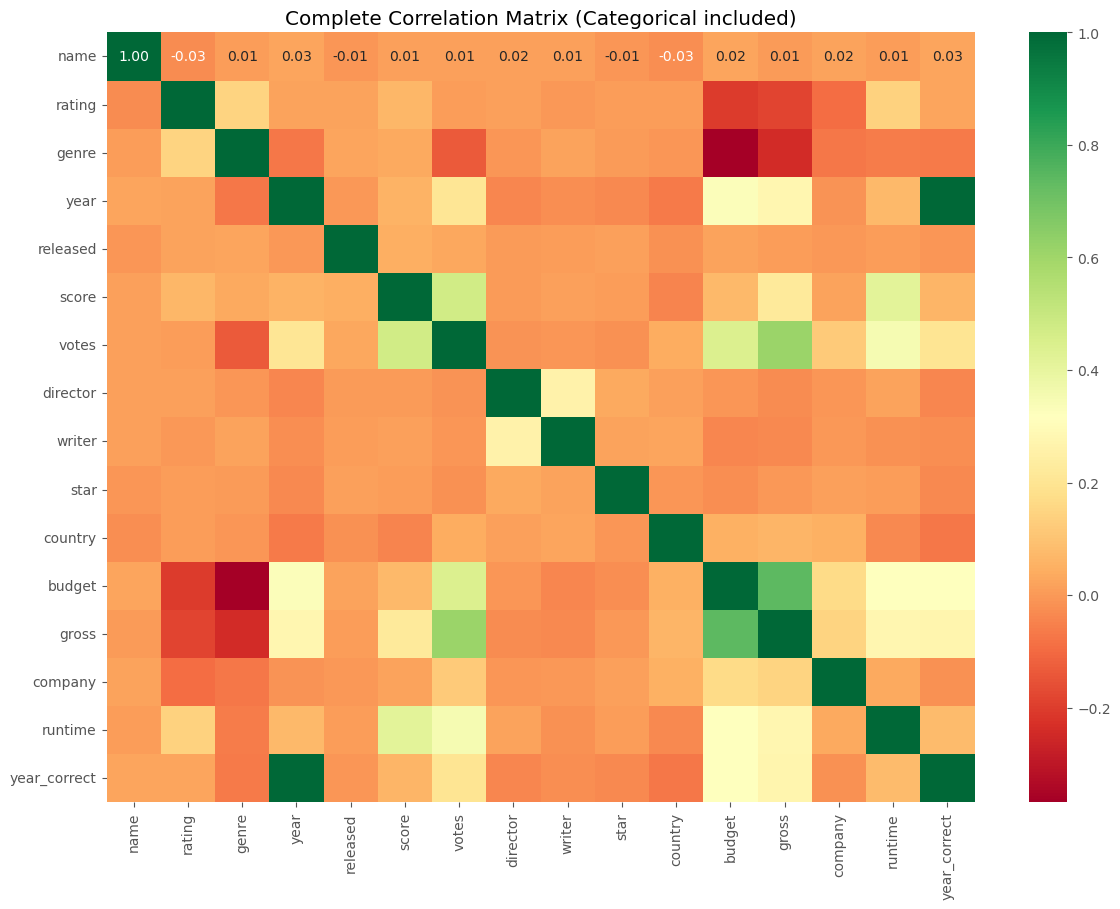

In [5]:
# 4. Advanced Correlation Analysis (Including Categorical Variables)

# Factorizing categoricals (Mapping string values to numeric IDs for correlation)
df_numerized = df.copy()
for col_name in df_numerized.columns:
    if df_numerized[col_name].dtype == 'object':
        df_numerized[col_name] = df_numerized[col_name].astype('category').cat.codes

correlation_matrix_all = df_numerized.corr(method='pearson')

plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Complete Correlation Matrix (Categorical included)')
plt.show()

In [6]:
# 5. Extracting highest correlations (Pairs)

# Unpacking the correlation matrix to find the strongest pairs (absolute value > 0.5)
correlation_pairs = correlation_matrix_all.unstack()
sorted_pairs = correlation_pairs.sort_values()

# Filtering for high correlations but rejecting identical pairs (1.0 vs 1.0)
high_corr = sorted_pairs[(abs(sorted_pairs) > 0.5) & (abs(sorted_pairs) < 1)]

print("Highest Correlations Among All Features:\\n")
print(high_corr)

Highest Correlations Among All Features:\n
gross         votes           0.614751
votes         gross           0.614751
gross         budget          0.740247
budget        gross           0.740247
year          year_correct    0.998726
year_correct  year            0.998726
dtype: float64
